In [1]:
import os
import sys
import numpy as np
import torch
from pathlib import Path
from tqdm import tqdm

# Add project to path
project_root = Path("/mnt/MKP01/med8_project/LuminaScale")
sys.path.insert(0, str(project_root))
os.environ["OCIO"] = str(project_root / "config" / "aces" / "studio-config.ocio")

# Import shared utilities
from src.luminascale.utils.dequant_utils import (
    load_dequant_model,
    create_gaussian_kernel,
    apply_gaussian_blur,
    compare_with_baseline,
    print_metrics_summary,
)
from src.luminascale.utils.dequantization_inference import (
    infer_dataset_with_comparison,
    save_inference_results,
)
from src.luminascale.training.dequantization_trainer import OnTheFlyBDEDataset

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Define paths
checkpoint_path = Path("/mnt/MKP01/med8_project/LuminaScale/dataset/temp/test_run/20260331_164330_dequant_net_epoch_1.pt")
lmdb_path = Path("/mnt/MKP01/med8_project/LuminaScale/dataset/training_data.lmdb")
output_dir = Path("/mnt/MKP01/med8_project/LuminaScale/outputs/inference")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint: {checkpoint_path}")
print(f"Checkpoint exists: {checkpoint_path.exists()}")

Device: cuda
Checkpoint: /mnt/MKP01/med8_project/LuminaScale/dataset/temp/test_run/20260331_164330_dequant_net_epoch_1.pt
Checkpoint exists: True


# Dequantization Model Inference

This notebook loads a single image and runs inference with the trained dequantization model:
1. Load pretrained model checkpoint
2. Load a single random test image
3. Run inference on the image
4. Display side-by-side comparison (LDR input, model output, ground truth)

## 1. Load Model & Setup Dataset

In [2]:
# Load model using shared utility
model = load_dequant_model(
    checkpoint_path=checkpoint_path,
    device=device,
    base_channels=32,
    num_levels=6,
)

print(f"✓ Model loaded. Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Note: For full-image inference, we'll load directly from LMDB without cropping
# The dataset will be created below with data loading utilities

✓ Model loaded. Total parameters: 78,633,539


## 2. Load a Single Image and Run Inference

In [3]:
## 2a. Helper Functions for Full-Image Inference from LMDB

import lmdb
import pickle

def load_full_image_from_lmdb(lmdb_path, key, device):
    """Load a full image from LMDB and run through full pipeline (no cropping)."""
    from src.luminascale.utils.look_generator import get_single_random_look
    
    env = lmdb.open(str(lmdb_path), readonly=True, lock=False, readahead=False, meminit=False)
    
    with env.begin(write=False) as txn:
        data = txn.get(key.encode('ascii') if isinstance(key, str) else key)
        if data is None:
            env.close()
            raise KeyError(f"Key {key} not found")
        
        # Parse ACES from LMDB
        import numpy as np
        header = np.frombuffer(data[:12], dtype=np.int32)
        H, W, C = int(header[0]), int(header[1]), int(header[2])
        
        # Extract HDR (full resolution, no cropping)
        hdr_size = H * W * C * 4
        hdr_arr = np.frombuffer(data[12:12+hdr_size], dtype=np.float32).reshape(C, H, W)
    
    env.close()
    
    # Convert to tensor and apply full pipeline
    from src.luminascale.utils.dataset_pair_generator import DatasetPairGenerator
    aces_tensor = torch.from_numpy(hdr_arr.astype(np.float32))
    
    # Apply CDL grading and OCIO transform to get sRGB variants
    from src.luminascale.utils.gpu_cdl_processor import GPUCDLProcessor
    from src.luminascale.utils.gpu_torch_processor import GPUTorchProcessor
    
    cdl_processor = GPUCDLProcessor(device=device)
    ocio_processor = GPUTorchProcessor(headless=True)
    
    # Move ACES to GPU and permute for processing [C, H, W] -> [H, W, C]
    aces_gpu = aces_tensor.to(device).permute(1, 2, 0)
    
    # Apply random CDL
    cdl_params = get_single_random_look()
    graded_aces = cdl_processor.apply_cdl_gpu(aces_gpu, cdl_params)
    
    # Apply OCIO display transform
    srgb_32f, srgb_8u = ocio_processor.apply_ocio_torch(graded_aces)
    
    # Cleanup
    cdl_processor.cleanup()
    ocio_processor.cleanup()
    
    return srgb_32f, srgb_8u  # Both [H, W, 3] on device

print("✓ Full-image inference utilities defined")

✓ Full-image inference utilities defined


In [ ]:
import matplotlib.pyplot as plt

# Get a random image key from LMDB
env = lmdb.open(str(lmdb_path), readonly=True, lock=False, readahead=False, meminit=False)
with env.begin(write=False) as txn:
    keys_buf = txn.get(b"__keys__")
    all_keys = pickle.loads(keys_buf)
env.close()

random_idx = np.random.randint(0, len(all_keys))
selected_key = all_keys[random_idx]
print(f"Loading full image {random_idx}: {selected_key}...")

# Load the FULL image (no cropping yet)
srgb_32f_full, srgb_8u_full = load_full_image_from_lmdb(lmdb_path, selected_key, device)
print(f"✓ Full image loaded. Shape: {srgb_8u_full.shape}")

# The model was trained on 512x512 crops, but it is fully convolutional.
# It requires dimensions to be divisible by 64 (due to 6 levels of pooling/upsampling).
# Store original size for reference
original_h, original_w = srgb_8u_full.shape[:2]

# Calculate target size: nearest dimensions divisible by 64
target_h = (original_h // 64) * 64
target_w = (original_w // 64) * 64

# Convert to float before interpolation (bilinear doesn't work on byte tensors)
srgb_32f_full = srgb_32f_full.float()
srgb_8u_full = srgb_8u_full.float() / 255.0  # Convert to [0, 1] range

# Resize to target size for model inference
import torch.nn.functional as F
srgb_32f_resized = srgb_32f_full.permute(2, 0, 1).unsqueeze(0)  # [1, 3, H, W]
srgb_8u_resized = srgb_8u_full.permute(2, 0, 1).unsqueeze(0)    # [1, 3, H, W]

srgb_32f_resized = F.interpolate(srgb_32f_resized, size=(target_h, target_w), mode='bilinear', align_corners=False)
srgb_8u_resized = F.interpolate(srgb_8u_resized, size=(target_h, target_w), mode='bilinear', align_corners=False)

# Prepare inputs
ldr = srgb_8u_resized  # [1, 3, target_h, target_w], already normalized to [0, 1]
hdr = srgb_32f_resized # [1, 3, target_h, target_w]

print(f"✓ Resized for inference: {original_h}x{original_w} → {target_h}x{target_w}")

# Run inference on resized image
with torch.no_grad():
    model_output = model(ldr.to(device))  # [1, 3, target_h, target_w]

print(f"✓ Inference complete for image {random_idx} at {target_h}x{target_w}")

Loading full image 283: 1049_3...


libEGL warning: pci id for fd 133: 10de:2206, driver (null)

pci id for fd 134: 10de:2206, driver (null)
pci id for fd 136: 10de:2206, driver (null)
libEGL warning: egl: failed to create dri2 screen
pci id for fd 134: 10de:2206, driver (null)
pci id for fd 136: 10de:2206, driver (null)
libEGL warning: egl: failed to create dri2 screen


✓ Full image loaded. Shape: torch.Size([2348, 3522, 3])
✓ Resized for inference: 2348x3522 → 512x512
✓ Inference complete for image 283 at 512x512


In [5]:
# Compute metrics for resized image
from src.luminascale.utils.dequant_utils import compute_metrics

model_np = model_output.squeeze(0).cpu().numpy()  # [3, 512, 512]
hdr_np = hdr.squeeze(0).cpu().numpy()  # [3, 512, 512]

metrics = compute_metrics(model_np, hdr_np)

print(f"\nImage {random_idx} Metrics (after resizing to 512x512):")
print(f"  Original size: {original_h} x {original_w} pixels")
print(f"  Inference size: {model_np.shape[1]} x {model_np.shape[2]} pixels")
print(f"  MSE:  {metrics['mse']:.6f}")
print(f"  PSNR: {metrics['psnr']:.2f} dB")
print(f"  SSIM: {metrics['ssim']:.4f}")


Image 283 Metrics (after resizing to 512x512):
  Original size: 2348 x 3522 pixels
  Inference size: 512 x 512 pixels
  MSE:  0.000001
  PSNR: 61.70 dB
  SSIM: 0.9999


## 3. Visualize Results


✓ Visualization saved to outputs/inference/full_image_inference.png


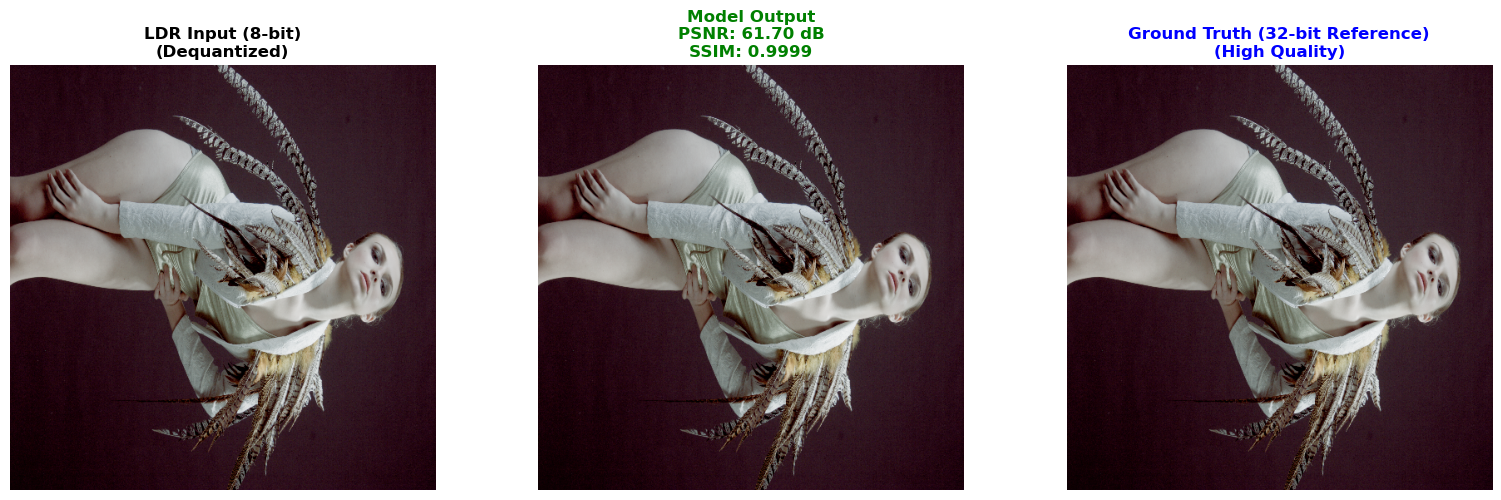

In [6]:
# Convert to display format [H, W, 3]
ldr_rgb = np.transpose(np.clip(ldr.squeeze(0).cpu().numpy(), 0, 1), (1, 2, 0))
model_rgb = np.transpose(np.clip(model_np, 0, 1), (1, 2, 0))
hdr_rgb = np.transpose(np.clip(hdr_np, 0, 1), (1, 2, 0))

# Create side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(ldr_rgb)
axes[0].set_title('LDR Input (8-bit)\n(Dequantized)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(model_rgb)
axes[1].set_title(f'Model Output\nPSNR: {metrics["psnr"]:.2f} dB\nSSIM: {metrics["ssim"]:.4f}', 
                  fontsize=12, fontweight='bold', color='green')
axes[1].axis('off')

axes[2].imshow(hdr_rgb)
axes[2].set_title('Ground Truth (32-bit Reference)\n(High Quality)', fontsize=12, fontweight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/mnt/MKP01/med8_project/LuminaScale/outputs/inference/full_image_inference.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Visualization saved to outputs/inference/full_image_inference.png")
plt.show()

✓ Full-image contrast comparison (10.0x) saved

🎯 High Contrast Analysis (10.0x boost):
  → LDR (left):   Shows clear 8-bit banding patterns
  → Model (mid):  Should show LESS banding than LDR if dequantization works
  → Reference (right): Smooth gradient (no banding at all)

Look closely: Is the middle image smoother than the left?


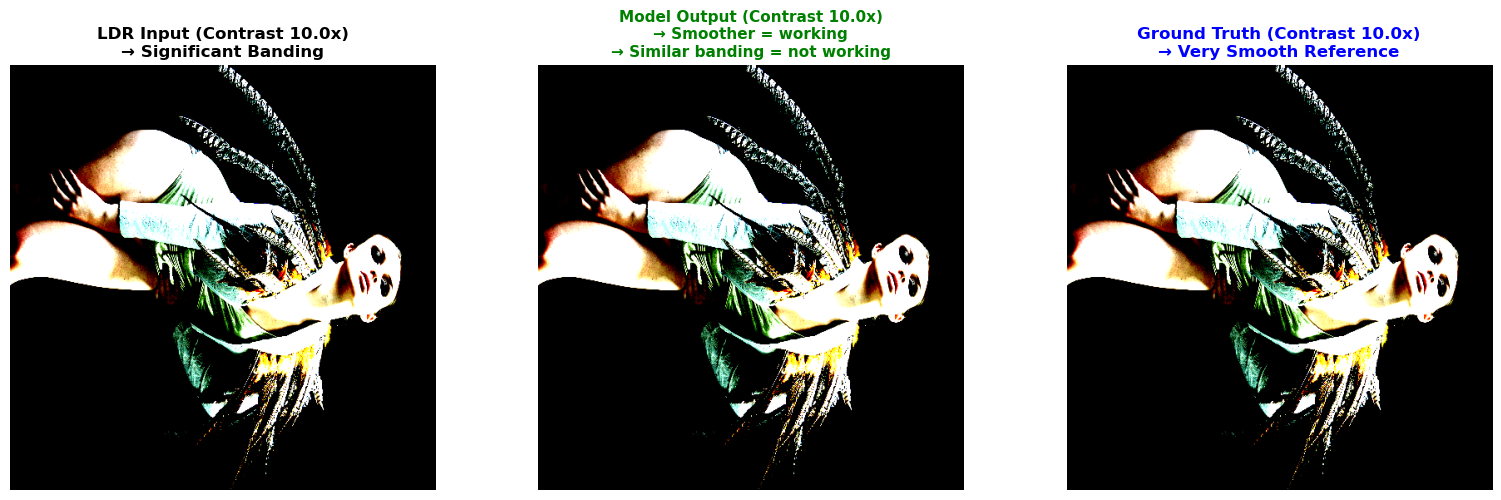

In [11]:
def apply_contrast(rgb_img, contrast_factor=2.0):
    """Apply contrast boost to reveal quantization banding.
    
    Contrast = (pixel - 0.5) * factor + 0.5
    """
    contrast_img = (rgb_img - 0.5) * contrast_factor + 0.5
    return np.clip(contrast_img, 0, 1)

contrast_boost = 10.0  # 50x for revealing banding

ldr_contrast = apply_contrast(ldr_rgb, contrast_boost)
model_contrast = apply_contrast(model_rgb, contrast_boost)
hdr_contrast = apply_contrast(hdr_rgb, contrast_boost)

# Create contrast comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(ldr_contrast)
axes[0].set_title(f'LDR Input (Contrast {contrast_boost}x)\n→ Significant Banding', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(model_contrast)
axes[1].set_title(f'Model Output (Contrast {contrast_boost}x)\n→ Smoother = working\n→ Similar banding = not working', 
                  fontsize=11, fontweight='bold', color='green')
axes[1].axis('off')

axes[2].imshow(hdr_contrast)
axes[2].set_title(f'Ground Truth (Contrast {contrast_boost}x)\n→ Very Smooth Reference', fontsize=12, fontweight='bold', color='blue')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/mnt/MKP01/med8_project/LuminaScale/outputs/inference/full_image_contrast_comparison.png', dpi=150, bbox_inches='tight')
print(f"✓ Full-image contrast comparison ({contrast_boost}x) saved")
print(f"\n🎯 High Contrast Analysis ({contrast_boost}x boost):")
print(f"  → LDR (left):   Shows clear 8-bit banding patterns")
print(f"  → Model (mid):  Should show LESS banding than LDR if dequantization works")
print(f"  → Reference (right): Smooth gradient (no banding at all)")
print(f"\nLook closely: Is the middle image smoother than the left?")
plt.show()

In [8]:
# Cleanup
print("✓ Full-image inference complete.")

✓ Full-image inference complete.
